In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Regular Expressions
import re

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Natural Language Processing
import nltk
from nltk.corpus import stopwords

# Download stopwords (Run only once)
nltk.download('stopwords')

# Machine Learning
from sklearn.model_selection import train_test_split

# TF-IDF Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib


[nltk_data] Downloading package stopwords to C:\Users\Ghanshyam
[nltk_data]     Choudhary\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [3]:
# Load the dataset
data = pd.read_csv("phishing_email.csv")


In [4]:
data.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [5]:
data.tail()

,text_combined,label
82481,info advantageapartmentscom infoadvantageapart...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...,1
82483,help center infohelpcentercoza_infohelpcenterc...,1
82484,metamask infosofamekarcom verify metamask wall...,1
82485,fastway infofastwaycoza_infofastwaycoza_infofa...,1


In [6]:
# Check number of rows and columns
data.shape

(82486, 2)

In [7]:
# Display all column names
data.columns

Index(['text_combined', 'label'], dtype='object')

In [8]:
# Display dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [9]:
# Check missing values in each column
data.isnull().sum()

text_combined    0
label            0
dtype: int64

In [10]:
# Check duplicate rows
data.duplicated().sum()

np.int64(408)

In [11]:
# Display basic statistics
data.describe(include='all')

,text_combined,label
count,82486,82486.000000
unique,82078,NaN
top,charity sees need cost dear friend read want f...,NaN
freq,3,NaN
mean,NaN,0.519979
std,NaN,0.499604
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,1.000000


In [ ]:
# ============================================================
# DATA CLEANING
# ============================================================

# Check missing values
data.isnull().sum()

text_combined    0
label            0
dtype: int64

In [13]:
# Remove missing values
data.dropna(inplace=True)

# Check dataset shape after removing missing values
data.shape

(82486, 2)

In [14]:
# Check duplicate rows
print("Duplicate Rows :", data.duplicated().sum())

# Remove duplicate rows
data.drop_duplicates(inplace=True)

# New dataset shape
print("New Shape :", data.shape)

Duplicate Rows : 408
New Shape : (82078, 2)


In [17]:
# Regular Expression
import re

# Stopwords
from nltk.corpus import stopwords

# Store English stopwords
stop_words = set(stopwords.words('english'))

In [18]:
# ============================================================
# Function to clean email text
# ============================================================

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML Tags
    text = re.sub(r'<.*?>', '', text)

    # Remove Numbers
    text = re.sub(r'\d+', '', text)

    # Remove Special Characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove Extra Spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove Stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    # Join words again
    text = " ".join(words)

    return text

In [19]:
# Clean all email text

data['clean_text'] = data['text_combined'].apply(clean_text)

In [20]:
# Compare original and cleaned email

data[['text_combined','clean_text']].head()

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...


In [21]:
# Check first 5 rows

data.head()

,text_combined,label,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,0,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,0,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,0,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,0,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,0,hpl nom june see attached file hplno xls hplno...


In [22]:
# Save cleaned dataset

data.to_csv("cleaned_phishing_email.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [ ]:
# ============================================================
#  EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Count the number of emails in each class
data['label'].value_counts()

label
1    42845
0    39233
Name: count, dtype: int64

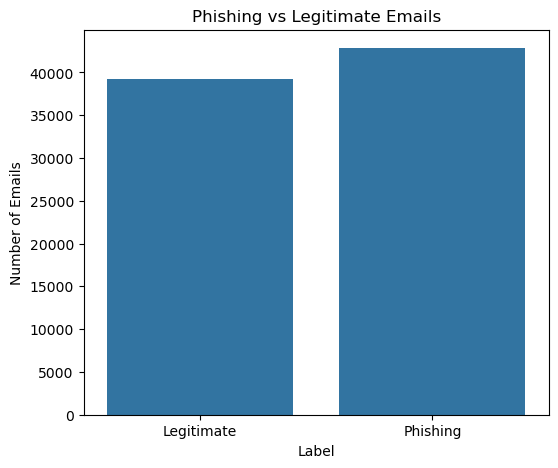

In [24]:
# Create a bar chart for label distribution

plt.figure(figsize=(6,5))

sns.countplot(x='label', data=data)

plt.title("Phishing vs Legitimate Emails")
plt.xlabel("Label")
plt.ylabel("Number of Emails")

plt.xticks([0,1],["Legitimate","Phishing"])

plt.show()

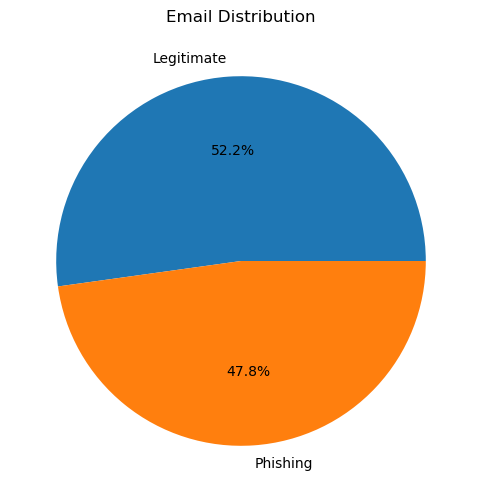

In [25]:
# Pie chart for label distribution

data['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=["Legitimate","Phishing"],
    figsize=(6,6)
)

plt.title("Email Distribution")
plt.ylabel("")

plt.show()

In [26]:
# Calculate email length

data["email_length"] = data["clean_text"].apply(len)

# Display first few values
data[["clean_text","email_length"]].head()

,clean_text,email_length
0,hpl nom may see attached file hplno xls hplno xls,49
1,nom actual vols th forwarded sabrae zajac hou ...,880
2,enron actuals march april estimated actuals ma...,109
3,hpl nom may see attached file hplno xls hplno xls,49
4,hpl nom june see attached file hplno xls hplno...,50


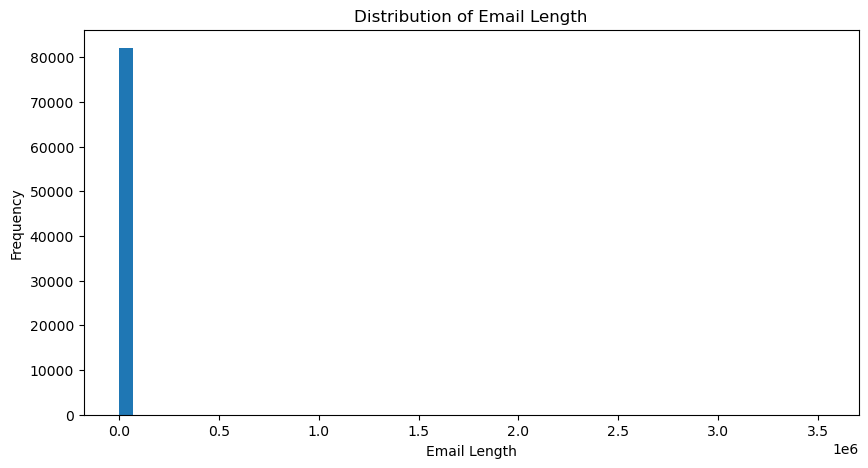

In [27]:
# Distribution of email length

plt.figure(figsize=(10,5))

plt.hist(data["email_length"], bins=50)

plt.title("Distribution of Email Length")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

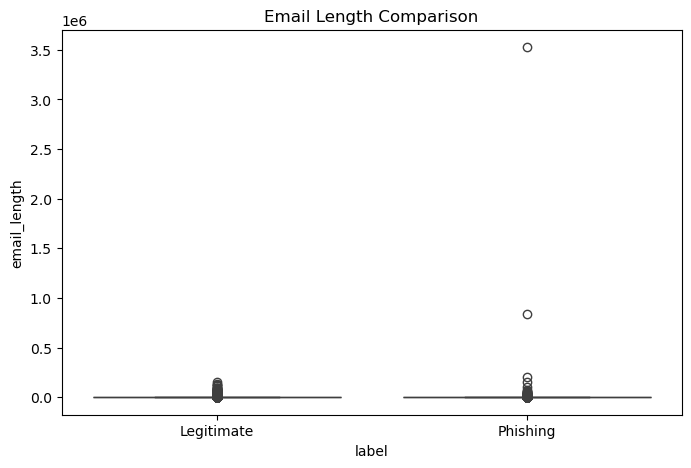

In [28]:
# Compare email length for each class

plt.figure(figsize=(8,5))

sns.boxplot(x="label", y="email_length", data=data)

plt.xticks([0,1],["Legitimate","Phishing"])

plt.title("Email Length Comparison")

plt.show()

In [29]:
# Combine all cleaned emails

all_words = " ".join(data["clean_text"])

# Split into words
word_list = all_words.split()

# Count word frequency
from collections import Counter

word_freq = Counter(word_list)

# Display top 20 words
word_freq.most_common(20)

[('enron', 52698),
 ('aug', 47870),
 ('email', 42828),
 ('please', 39762),
 ('new', 36240),
 ('one', 35865),
 ('ect', 34075),
 ('submissionid', 32246),
 ('would', 31253),
 ('time', 30076),
 ('company', 29599),
 ('information', 27745),
 ('us', 27735),
 ('get', 27647),
 ('top', 26367),
 ('may', 25337),
 ('com', 23509),
 ('message', 23088),
 ('list', 22858),
 ('also', 22621)]

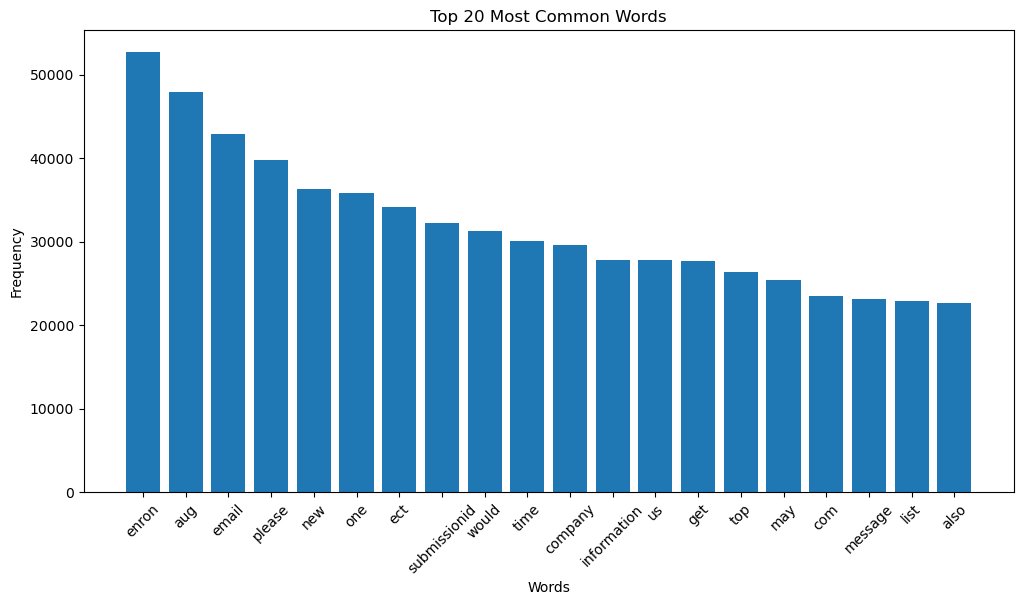

In [30]:
# Top 20 most common words

top_words = word_freq.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Most Common Words")

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

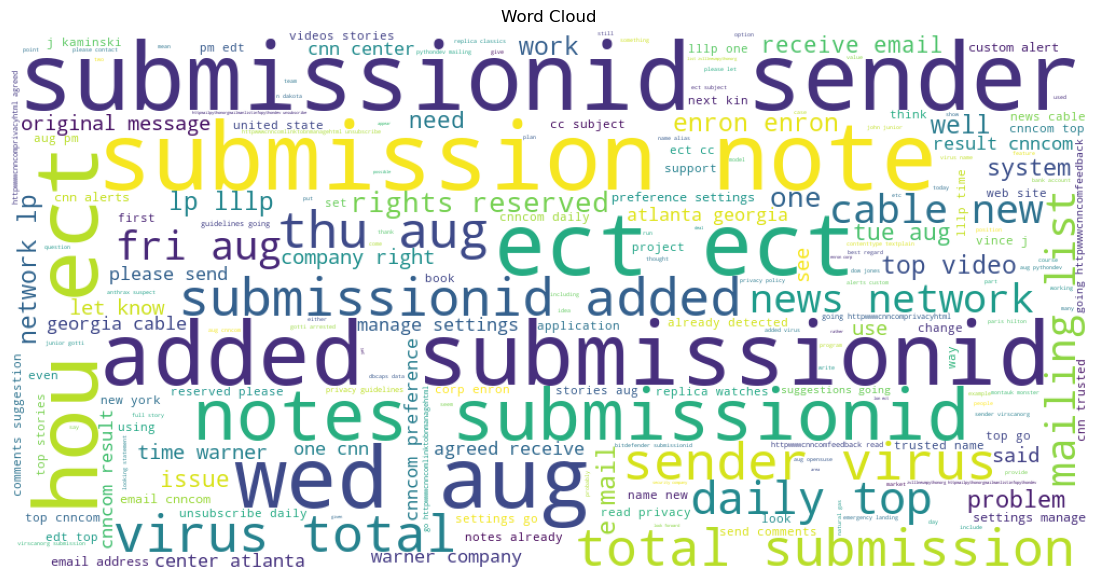

In [32]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")

plt.show()

In [33]:
# Summary of email length

data["email_length"].describe()

count    8.207800e+04
mean     1.188904e+03
std      1.295120e+04
min      0.000000e+00
25%      2.460000e+02
50%      5.090000e+02
75%      1.249000e+03
max      3.526398e+06
Name: email_length, dtype: float64

In [ ]:
# ============================================================
#  TF-IDF FEATURE EXTRACTION
# ============================================================

# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
# Input Feature (Email Text)
X = data["clean_text"]

# Target Variable
y = data["label"]

In [36]:
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    max_features=5000,      # Keep top 5000 important words
    stop_words='english',   # Remove English stopwords
    lowercase=True          # Convert all words to lowercase
)

In [37]:
# Convert email text into TF-IDF vectors

X = tfidf.fit_transform(X)

In [38]:
# Display TF-IDF matrix shape

print("Shape of TF-IDF Matrix :", X.shape)

Shape of TF-IDF Matrix : (82078, 5000)


In [39]:
# Display first 20 feature names

print(tfidf.get_feature_names_out()[:20])

['aa' 'aaron' 'ab' 'abacha' 'abandoned' 'abidjan' 'ability' 'able'
 'abroad' 'absence' 'absolute' 'absolutely' 'abstract' 'abstracts'
 'absurd' 'abuse' 'ac' 'academic' 'academy' 'accept']


In [40]:
# Convert first 5 rows into DataFrame

tfidf_df = pd.DataFrame(
    X[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aa,aaron,ab,abacha,abandoned,abidjan,ability,able,abroad,absence,...,zdnet,ze,zealand,zero,zimbabwe,zimin,zip,zone,zoo,zvlllneumpythonorg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
# Save TF-IDF Vectorizer

import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer Saved Successfully.")

TF-IDF Vectorizer Saved Successfully.


In [ ]:
# ============================================================
#  TRAIN-TEST SPLIT
# ============================================================

# Import train_test_split
from sklearn.model_selection import train_test_split

In [43]:
# Split dataset into Training (80%) and Testing (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X,                      # TF-IDF Features
    y,                      # Target Labels
    test_size=0.20,         # 20% for Testing
    random_state=42,        # Fixed random state for reproducibility
    stratify=y              # Maintain the same class distribution
)

In [44]:
# Display shapes of training and testing data

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print()

print("Training Label Shape   :", y_train.shape)
print("Testing Label Shape    :", y_test.shape)

Training Feature Shape : (65662, 5000)
Testing Feature Shape  : (16416, 5000)

Training Label Shape   : (65662,)
Testing Label Shape    : (16416,)


In [45]:
# Check class distribution after splitting

print("Training Labels")
print(y_train.value_counts())

print("\nTesting Labels")
print(y_test.value_counts())

Training Labels
label
1    34276
0    31386
Name: count, dtype: int64

Testing Labels
label
1    8569
0    7847
Name: count, dtype: int64


In [47]:
# Display train-test percentage

train_percent = (X_train.shape[0] / X.shape[0]) * 100
test_percent = (X_test.shape[0] / X.shape[0]) * 100

print(f"Training Data : {train_percent:.2f}%")
print(f"Testing Data  : {test_percent:.2f}%")

Training Data : 80.00%
Testing Data  : 20.00%


In [ ]:
# ============================================================
#  LOGISTIC REGRESSION
# ============================================================

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [49]:
# Create Logistic Regression Model

lr_model = LogisticRegression(random_state=42)

In [50]:
# Train the Logistic Regression Model

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [51]:
# Predict labels for test data

lr_prediction = lr_model.predict(X_test)

In [52]:
# Calculate Accuracy

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_prediction)

print("Accuracy :", lr_accuracy)

Accuracy : 0.9791057504873294


In [53]:
from sklearn.metrics import precision_score

lr_precision = precision_score(y_test, lr_prediction)

print("Precision :", lr_precision)

Precision : 0.9785897137537817


In [54]:
from sklearn.metrics import recall_score

lr_recall = recall_score(y_test, lr_prediction)

print("Recall :", lr_recall)

Recall : 0.9814447426770918


In [55]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, lr_prediction)

print("F1 Score :", lr_f1)

F1 Score : 0.9800151488667482


In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_prediction)

print(cm)

[[7663  184]
 [ 159 8410]]


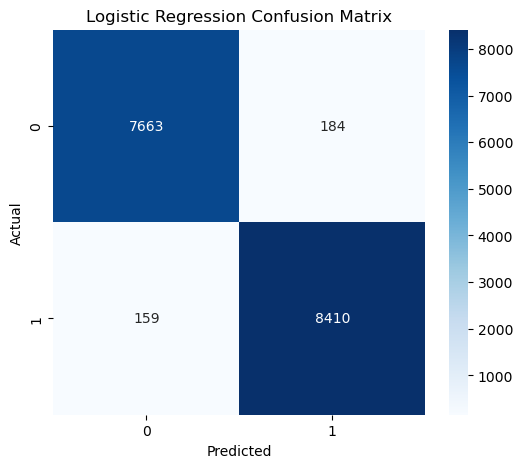

In [57]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_prediction))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [ ]:
# ============================================================
#  NAIVE BAYES
# ============================================================

from sklearn.naive_bayes import MultinomialNB

In [60]:
# Create Naive Bayes Model

nb_model = MultinomialNB()

In [61]:
# Train Model

nb_model.fit(X_train, y_train)

print("Naive Bayes Model Trained Successfully.")

Naive Bayes Model Trained Successfully.


In [62]:
# Prediction

nb_prediction = nb_model.predict(X_test)

In [63]:
print("Accuracy :", accuracy_score(y_test, nb_prediction))

Accuracy : 0.9592470760233918


In [64]:
print("Precision :", precision_score(y_test, nb_prediction))

Precision : 0.9769379376962086


In [65]:
print("Recall :", recall_score(y_test, nb_prediction))

Recall : 0.9442175282996849


In [66]:
print("F1 Score :", f1_score(y_test, nb_prediction))

F1 Score : 0.9602990920420154


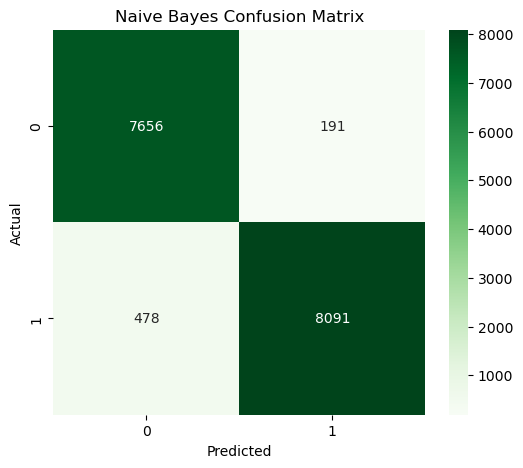

In [67]:
cm = confusion_matrix(y_test, nb_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [68]:
print(classification_report(y_test, nb_prediction))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7847
           1       0.98      0.94      0.96      8569

    accuracy                           0.96     16416
   macro avg       0.96      0.96      0.96     16416
weighted avg       0.96      0.96      0.96     16416



In [ ]:
# ============================================================
#  RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

In [70]:
# Create Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [71]:
# Train Model

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


In [72]:
# Prediction

rf_prediction = rf_model.predict(X_test)

In [73]:
print("Accuracy :", accuracy_score(y_test, rf_prediction))

Accuracy : 0.9835526315789473


In [74]:
print("Precision :", precision_score(y_test, rf_prediction))

Precision : 0.9844716870986573


In [75]:
print("Recall :", recall_score(y_test, rf_prediction))

Recall : 0.9840121367720854


In [76]:
print("F1 Score :", f1_score(y_test, rf_prediction))

F1 Score : 0.9842418582934516


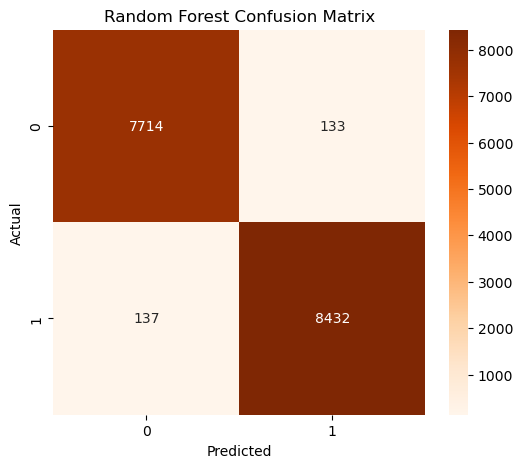

In [77]:
cm = confusion_matrix(y_test, rf_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [78]:
print(classification_report(y_test, rf_prediction))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [ ]:
# ============================================================
#  MODEL EVALUATION & COMPARISON
# ============================================================

# Import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create comparison table
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_prediction),
        accuracy_score(y_test, nb_prediction),
        accuracy_score(y_test, rf_prediction)
    ],

    "Precision": [
        precision_score(y_test, lr_prediction),
        precision_score(y_test, nb_prediction),
        precision_score(y_test, rf_prediction)
    ],

    "Recall": [
        recall_score(y_test, lr_prediction),
        recall_score(y_test, nb_prediction),
        recall_score(y_test, rf_prediction)
    ],

    "F1 Score": [
        f1_score(y_test, lr_prediction),
        f1_score(y_test, nb_prediction),
        f1_score(y_test, rf_prediction)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.979106,0.978590,0.981445,0.980015
1,Naive Bayes,0.959247,0.976938,0.944218,0.960299
2,Random Forest,0.983553,0.984472,0.984012,0.984242


In [80]:
# Display values up to 4 decimal places

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9791,0.9786,0.9814,0.9800
1,Naive Bayes,0.9592,0.9769,0.9442,0.9603
2,Random Forest,0.9836,0.9845,0.9840,0.9842


In [81]:
# Find model with highest accuracy

best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Model")

print(best_model)

Best Model
Model        Random Forest
Accuracy            0.9836
Precision           0.9845
Recall               0.984
F1 Score            0.9842
Name: 2, dtype: object


In [82]:
# Sort models from highest to lowest accuracy

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.9836,0.9845,0.9840,0.9842
0,Logistic Regression,0.9791,0.9786,0.9814,0.9800
1,Naive Bayes,0.9592,0.9769,0.9442,0.9603


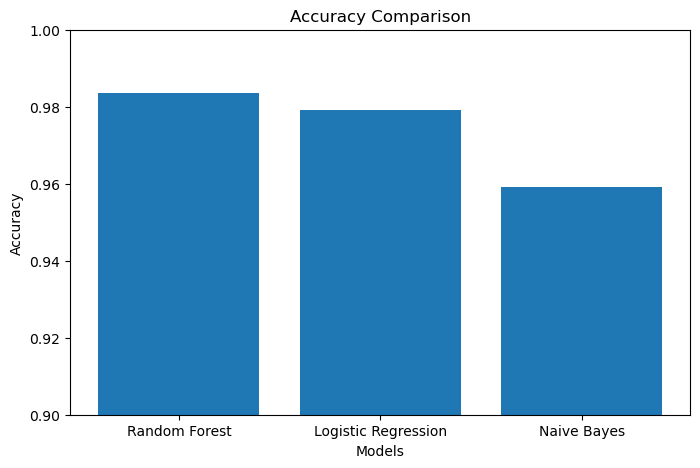

In [83]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

plt.show()

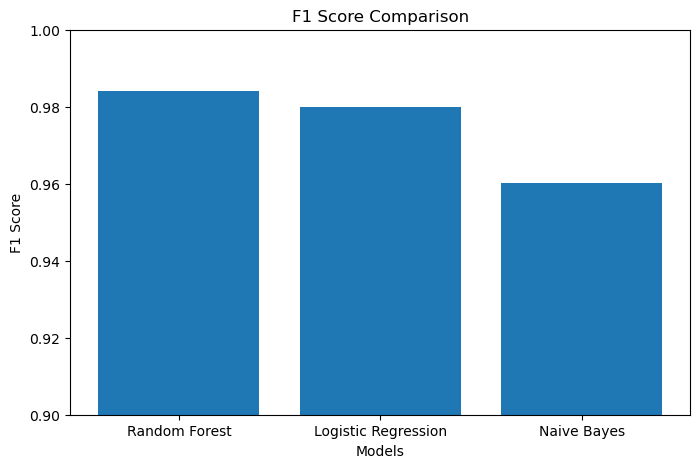

In [84]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["F1 Score"])

plt.title("F1 Score Comparison")

plt.xlabel("Models")

plt.ylabel("F1 Score")

plt.ylim(0.90,1.00)

plt.show()

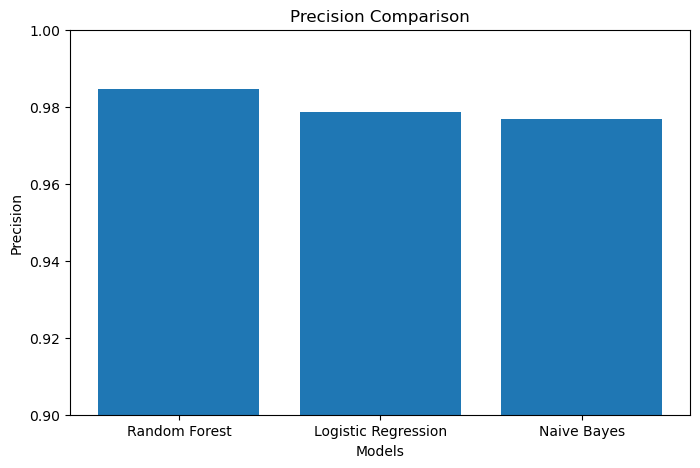

In [85]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Precision"])

plt.title("Precision Comparison")

plt.xlabel("Models")

plt.ylabel("Precision")

plt.ylim(0.90,1.00)

plt.show()

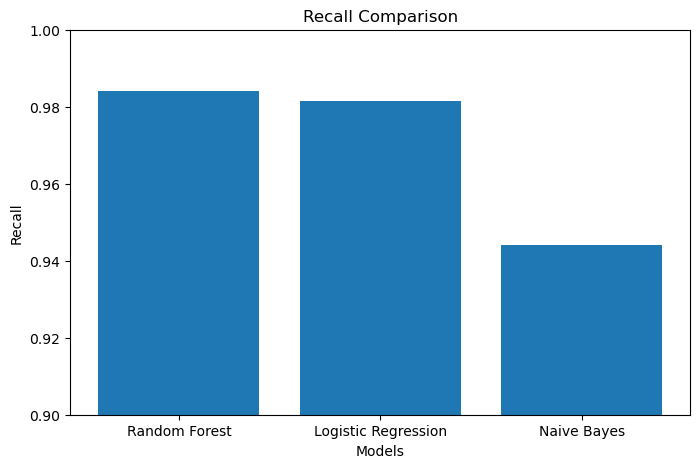

In [86]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Recall"])

plt.title("Recall Comparison")

plt.xlabel("Models")

plt.ylabel("Recall")

plt.ylim(0.90,1.00)

plt.show()

In [87]:
# Save model comparison table

results.to_csv("model_comparison_results.csv", index=False)

print("Comparison table saved successfully.")

Comparison table saved successfully.


In [ ]:
# ============================================================
#  SAVE BEST MODEL
# ============================================================

# Import Joblib
import joblib

In [89]:
# Save Random Forest Model

joblib.dump(rf_model, "phishing_email_model.pkl")

print("Model Saved Successfully.")

Model Saved Successfully.


In [90]:
# Save TF-IDF Vectorizer

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer Saved Successfully.")

TF-IDF Vectorizer Saved Successfully.


In [91]:
# Load Saved Model

loaded_model = joblib.load("phishing_email_model.pkl")

print("Model Loaded Successfully.")

Model Loaded Successfully.


In [92]:
# Load Saved TF-IDF Vectorizer

loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("TF-IDF Loaded Successfully.")

TF-IDF Loaded Successfully.


In [93]:
# Sample Email

sample_email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

# Transform using Saved TF-IDF

sample_vector = loaded_tfidf.transform(sample_email)

# Predict

prediction = loaded_model.predict(sample_vector)

print("Prediction :", prediction)

Prediction : [1]


In [94]:
# Display Final Prediction

if prediction[0] == 1:
    print("🚨 Phishing Email Detected")
else:
    print("✅ Legitimate Email")

🚨 Phishing Email Detected


In [95]:
# Verify Saved Files

import os

print(os.listdir())

['.ipynb_checkpoints', 'cleaned_phishing_email.csv', 'model_comparison_results.csv', 'phishing_email.csv', 'phishing_email_model.pkl', 'phising_email_model.ipynb', 'tfidf_vectorizer.pkl']
